In [1]:
#Input files
import pandas as pd
from pathlib import Path

#read input files 
input_file = Path(r"C:\Users\menne\Documents\Master\Thesis\Data\Capacities\nameplate_capacity.csv") #Calliope model output
baseline_input = Path(r"C:\Users\menne\Documents\Master\Thesis\Data\Capacities\nameplate_capacity_2025.csv") #IRENA data
input_vintage = Path(r"C:\Users\menne\Documents\Master\Thesis\Data\Capacities\capacity_vintages_EU.csv") #Vintages
material_input = Path(r"C:\Users\menne\Documents\Master\Thesis\Data\Material\material_intensities.csv") #Material intensities


df = pd.read_csv(input_file)
df_2025 = pd.read_csv(baseline_input, sep=";")
material_intensities = pd.read_csv(material_input, sep=";")

with open(input_vintage, "r", encoding="utf-8-sig") as f:
    first_line = f.readline().strip().lower()

skiprows = 1 if first_line.startswith("sep=") else 0

df_vintage = pd.read_csv(
    input_vintage,
    sep=";",
    skiprows=skiprows
)


In [2]:
# read all csv's correctly 

#df_2025
df_2025 = df_2025.copy()
df_2025.columns = df_2025.columns.str.strip()

# Tech en country opschonen
df_2025["tech"] = df_2025["tech"].str.strip()
df_2025["country"] = df_2025["country"].str.strip()

# capacity (TW) als getal inlezen
df_2025["capacity (TW)"] = (
    df_2025["capacity (TW)"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df_2025["capacity (TW)"] = pd.to_numeric(
    df_2025["capacity (TW)"],
    errors="coerce"
).fillna(0)

#df_vintage
df_vintage = df_vintage.copy()
df_vintage.columns = df_vintage.columns.str.strip()

df_vintage["country"] = df_vintage["country"].astype(str).str.strip()
df_vintage["tech"] = df_vintage["tech"].astype(str).str.strip().str.lower()

df_vintage["vintage_year"] = pd.to_numeric(
    df_vintage["vintage_year"],
    errors="coerce"
).astype("Int64")

# BELANGRIJK: komma's vervangen door punten voordat je naar numeric converteert
df_vintage["capacity_TW"] = (
    df_vintage["capacity_TW"]
    .astype(str)
    .str.strip()
    .str.replace(",", ".", regex=False)
)

df_vintage["capacity_TW"] = pd.to_numeric(
    df_vintage["capacity_TW"],
    errors="coerce"
).fillna(0)

In [3]:
#Support dictionary
# Select weather year 2018 for analysis
df_2018 = df[df["weather_year"] == 2018].copy()

# Merge hubs from same countries
df_2018["country"] = df_2018["locs"].str.split("_").str[0]

# Capacity must be numeric
df_2018["nameplate_capacity"] = pd.to_numeric(
    df_2018["nameplate_capacity"],
    errors="coerce"
)

# Add up capacities for each country and technology
result = (
    df_2018
    .groupby(["country", "techs"], as_index=False)["nameplate_capacity"]
    .sum()
    .sort_values(["country", "techs"])
)


# Dictionary : {country: {tech: capacity}}
capacity_dict = {}

for _, row in result.iterrows():
    country = row["country"]
    tech = row["techs"]
    capacity = row["nameplate_capacity"]

    if pd.notna(capacity):
        if country not in capacity_dict:
            capacity_dict[country] = {}

        capacity_dict[country][tech] = capacity


In [4]:
# Only take into account EU countries (minus Malta) and some technologies
EU_countries = [
    "AUT",  # Austria
    "BEL",  # Belgium
    "BGR",  # Bulgaria
    "CYP",  # Cyprus
    "CZE",  # Czechia
    "DEU",  # Germany
    "DNK",  # Denmark
    "ESP",  # Spain
    "EST",  # Estonia
    "FIN",  # Finland
    "FRA",  # France
    "GRC",  # Greece
    "HRV",  # Croatia
    "HUN",  # Hungary
    "IRL",  # Ireland
    "ITA",  # Italy
    "LVA",  # Latvia
    "LTU",  # Lithuania
    "LUX",  # Luxembourg
    "NLD",  # Netherlands
    "POL",  # Poland
    "PRT",  # Portugal
    "ROU",  # Romania
    "SVK",  # Slovakia
    "SVN",  # Slovenia
    "SWE",  # Sweden
]
 
tech_groups = {
    "solar": ["open_field_pv", "roof_mounted_pv"],
    "onshore wind": ["wind_onshore"],
    "offshore wind": ["wind_offshore"],
    "bioenergy": ["biofuel_supply"],
    "batteries": ["battery"],
    #"wind": {"wind_onshore", "wind_offshore"}
}


In [5]:
#Capacities 2025
# Dictionary 1:
# {Counry: {technology: capacity_2025}}
EU_capacities_2025 = {}

for country in EU_countries:
    EU_capacities_2025[country] = {}

    for tech_group in tech_groups:
        total_capacity = df_2025.loc[
            (df_2025["country"] == country) &
            (df_2025["tech"] == tech_group),
            "capacity (TW)"
        ].sum()

        EU_capacities_2025[country][tech_group] = float(total_capacity)


# Dictionary 2:
# {Technology: total_EU_capacity_2025}
EU_total_capacities_2025 = {}

for tech_group in tech_groups:
    total_capacity = 0

    for country in EU_capacities_2025:
        total_capacity += EU_capacities_2025[country][tech_group]

    EU_total_capacities_2025[tech_group] = float(total_capacity)


# Print dictionary 1
print("EU capacities per country in 2025 (TW):")
for country, techs in EU_capacities_2025.items():
    print(country, techs)

# Print dictionary 2
print("\nTotal EU capacities in 2025 (TW):")
for tech_group, capacity in EU_total_capacities_2025.items():
    print(f"{tech_group}: {capacity:.6f} TW")

EU capacities per country in 2025 (TW):
AUT {'solar': 0.010304, 'onshore wind': 0.004292, 'offshore wind': 0.0, 'bioenergy': 0.001176, 'batteries': 5.2e-05}
BEL {'solar': 0.010398, 'onshore wind': 0.003589, 'offshore wind': 0.002262, 'bioenergy': 0.00073, 'batteries': 0.000491}
BGR {'solar': 0.00591, 'onshore wind': 0.000706, 'offshore wind': 0.0, 'bioenergy': 9.1e-05, 'batteries': 0.000766}
CYP {'solar': 0.000861, 'onshore wind': 0.00017, 'offshore wind': 0.0, 'bioenergy': 1.1e-05, 'batteries': 0.0}
CZE {'solar': 0.004541, 'onshore wind': 0.000369, 'offshore wind': 0.0, 'bioenergy': 0.000853, 'batteries': 4.3e-05}
DEU {'solar': 0.106272, 'onshore wind': 0.068135, 'offshore wind': 0.009673, 'bioenergy': 0.010067, 'batteries': 0.002903}
DNK {'solar': 0.005046, 'onshore wind': 0.004903, 'offshore wind': 0.002644, 'bioenergy': 0.001961, 'batteries': 0.000106}
ESP {'solar': 0.044903, 'onshore wind': 0.033296, 'offshore wind': 5e-06, 'bioenergy': 0.001314, 'batteries': 0.000298}
EST {'solar

In [6]:
#Capacities 2050
# Dictionary 1:
# {Counry: {technology: capacity_2050}}
EU_capacities_2050 = {}

for country in EU_countries:
    # Alleen landen meenemen die daadwerkelijk in capacity_dict staan
    if country in capacity_dict:
        EU_capacities_2050[country] = {}

        for tech_group, model_techs in tech_groups.items():
            total_capacity_EU = 0

            for model_tech in model_techs:
                total_capacity_EU += capacity_dict[country].get(model_tech, 0)

            EU_capacities_2050[country][tech_group] = total_capacity_EU


# Dictionary 2:
# {Technology: total_EU_capacity_2050}
EU_total_capacities_2050 = {}

for tech_group in tech_groups:
    total_capacity_EU = 0

    for country in EU_capacities_2050:
        total_capacity_EU += EU_capacities_2050[country][tech_group]

    EU_total_capacities_2050[tech_group] = total_capacity_EU


# Print dictionary 1
print("EU capacities per country in 2050 (TW):")
for country, techs in EU_capacities_2050.items():
    print(country, techs)

# Print dictionary 2
print("\nTotal EU capacities in 2050 (TW):")
for tech_group, capacity in EU_total_capacities_2050.items():
    print(f"{tech_group}: {capacity:.6f}")

EU capacities per country in 2050 (TW):
AUT {'solar': 0.000547909168113024, 'onshore wind': 0.07557476986390281, 'offshore wind': 0, 'bioenergy': 0.0275326608207749, 'batteries': 0.00010002048801541452}
BEL {'solar': 0.05078061613416606, 'onshore wind': 0.0182481707633423, 'offshore wind': 4.23248328153697e-06, 'bioenergy': 0.0211099270521514, 'batteries': 3.1164506756140484e-05}
BGR {'solar': 0.0322539268721401, 'onshore wind': 1.961302109750942e-05, 'offshore wind': 3.071684273710009e-06, 'bioenergy': 0.0130712454622553, 'batteries': 4.875787917188682e-05}
CYP {'solar': 0.00839659129402937, 'onshore wind': 0.00312730484216, 'offshore wind': 2.4983293618681943e-06, 'bioenergy': 0.0002465988958544, 'batteries': 6.659282282767267e-05}
CZE {'solar': 0.006886470689417586, 'onshore wind': 0.07728147849300358, 'offshore wind': 0, 'bioenergy': 0.0261475597197483, 'batteries': 7.921386652788787e-05}
DEU {'solar': 0.5156098209604957, 'onshore wind': 0.1631909220242309, 'offshore wind': 1.39861

In [7]:
# Capacity difference per country from 2025 to 2050
EU_difference = {}
for country in EU_countries:
    EU_difference [country] = {}
    
    for tech in EU_total_capacities_2025.keys():
        difference = EU_capacities_2050[country].get(tech,0) - EU_capacities_2025[country].get(tech,0)
        EU_difference[country][tech]=difference
    
# Total capacity difference from 2025 to 2050    
EU_total_difference = {}
EU_relative_difference = {}
for tech in EU_total_capacities_2050.keys():
    difference = EU_total_capacities_2050[tech] - EU_total_capacities_2025[tech]
    EU_total_difference[tech] = difference
    if EU_total_capacities_2025[tech] > 0:
        EU_relative_difference[tech] = round(difference / EU_total_capacities_2025[tech] *100, 2)
    else:
        EU_relative_difference[tech] = "N.A."
    
    
# Print dictionary 1
print("EU capacities differences per country in 2050 (TW):")
for country, techs in EU_difference.items():
    print(country, techs)

# Print dictionary 2
print("\nTotal EU capacity difference in 2050 (TW):")
for tech_group, capacity in EU_total_difference.items():
    print(f"{tech_group}: {capacity:.6f} (+{EU_relative_difference[tech_group]}% from 2025 to 2050)")
    

EU capacities differences per country in 2050 (TW):
AUT {'solar': -0.009756090831886976, 'onshore wind': 0.0712827698639028, 'offshore wind': 0.0, 'bioenergy': 0.0263566608207749, 'batteries': 4.802048801541452e-05}
BEL {'solar': 0.04038261613416606, 'onshore wind': 0.0146591707633423, 'offshore wind': -0.002257767516718463, 'bioenergy': 0.020379927052151397, 'batteries': -0.0004598354932438595}
BGR {'solar': 0.0263439268721401, 'onshore wind': -0.0006863869789024906, 'offshore wind': 3.071684273710009e-06, 'bioenergy': 0.0129802454622553, 'batteries': -0.0007172421208281131}
CYP {'solar': 0.007535591294029371, 'onshore wind': 0.00295730484216, 'offshore wind': 2.4983293618681943e-06, 'bioenergy': 0.0002355988958544, 'batteries': 6.659282282767267e-05}
CZE {'solar': 0.002345470689417586, 'onshore wind': 0.07691247849300359, 'offshore wind': 0.0, 'bioenergy': 0.0252945597197483, 'batteries': 3.621386652788787e-05}
DEU {'solar': 0.40933782096049565, 'onshore wind': 0.09505592202423091, '

In [8]:
# Model parameters
techs = ["solar", "onshore wind", "offshore wind", "batteries" #, "wind"
         ]

tech_params = {
    "solar": {"lifetime": 30, "beta": 4, "k": 0.2, "t0": 2030},
    "onshore wind": {"lifetime": 25, "beta": 4, "k": 0.2, "t0": 2008},
    "offshore wind": {"lifetime": 25, "beta": 4, "k": 0.2, "t0": 2008},
    "batteries": {"lifetime": 15, "beta": 4, "k": 0.2, "t0": 2030},
    #"wind": {"lifetime": 25, "beta": 4, "k": 0.2, "t0": 2030}
}

biofuel_params ={
    "k" : 0.3,
    "t0" : 2035
}
start_year = 2025
end_year = 2050


In [9]:
# Model functions
import math

# Growth functions
def linear_growth(cap_begin, cap_end):
    return cap_begin + (cap_end - cap_begin)* years_after_start/ (end_year - start_year)


def logistic_growth(year, cap_begin, cap_end, k, t0):
    
    raw_start = 1 / (1 + math.exp(-k * (start_year - t0)))
    raw_end = 1 / (1 + math.exp(-k * (end_year - t0)))
    raw_year = 1 / (1 + math.exp(-k * (year - t0)))

    s = (raw_year - raw_start) / (raw_end - raw_start)

    if cap_end > cap_begin:
        return cap_begin + (cap_end - cap_begin) * s
    else:
        return cap_begin + (cap_end - cap_begin)* years_after_start/ (end_year - start_year)

def gompertz_growth(year, cap_begin, cap_end, k, t0):
   
    raw_start = math.exp(-math.exp(-k * (start_year - t0)))
    raw_end = math.exp(-math.exp(-k * (end_year - t0)))
    raw_year = math.exp(-math.exp(-k * (year - t0)))

    s = (raw_year - raw_start) / (raw_end - raw_start)

    if cap_end > cap_begin:
        return cap_begin + (cap_end - cap_begin) * s
    else:
        return cap_begin + (cap_end - cap_begin)* years_after_start/ (end_year - start_year)
    
# Weibull function 
def weibull(year, vintage_year, lifetime, beta):
    """
    Survival fraction of capacity built in vintage_year and observed in year.

    This assumes vintage capacity = capacity originally built in that vintage year.
    """
    age = year - vintage_year

    if age < 0:
        return 0

    return math.exp(-((age / lifetime) ** beta))    

In [10]:
# biofuel use per year

annual_biofuel_use = {}
biofuel_total = {
    year: 0
    for year in range(start_year + 1, end_year + 1)
}
for country in EU_countries:
    annual_biofuel_use [country] = {}
    
    biofuel_use_2025 = EU_capacities_2025[country]["bioenergy"]
    biofuel_use_2050 = EU_capacities_2050[country]["bioenergy"]
    
    for year in range(start_year + 1, end_year + 1):
            
            years_after_start = year - start_year
                        
            biofuel_use = linear_growth(cap_begin = biofuel_use_2025,
                                        cap_end = biofuel_use_2050)
            
            annual_biofuel_use[country][year] = biofuel_use
            biofuel_total[year] += biofuel_use

In [11]:
# Annual buildout calculation
# annual_buildout[country][tech][year] = required new capacity
annual_buildout = {}

# vintage_dict[country][tech] = newly built capacity
vintage_dict = {}

# DataFrame output
records = []


for country in EU_countries:
    annual_buildout[country] = {}
    vintage_dict[country] = {}

    for tech in techs:
        params = tech_params[tech]

        lifetime = params["lifetime"]
        beta = params["beta"]
        k = params["k"]
        t0 = params["t0"]

        capacity_2025 = float(EU_capacities_2025[country][tech])
        capacity_2050 = float(EU_capacities_2050[country][tech])

        annual_buildout[country][tech] = {}

        # Add existing Vintages from before 2026
        vintage_rows = df_vintage.loc[
            (df_vintage["country"] == country) &
            (df_vintage["tech"] == tech)
        ]

        vintages = []

        for _, vintage_row in vintage_rows.iterrows():
            vintages.append({
                "year": int(vintage_row["vintage_year"]),
                "capacity": float(vintage_row["capacity_TW"])
            })


       # Scale Vintages to match 2025 capacity 
        surviving_vintage_capacity_2025 = 0

        for vintage in vintages:
            if vintage["year"] <= start_year:
                survival_2025 = weibull(
                    year=start_year,
                    vintage_year=vintage["year"],
                    lifetime=lifetime,
                    beta=beta
                )

                surviving_vintage_capacity_2025 += vintage["capacity"] * survival_2025


        if surviving_vintage_capacity_2025 > 0 and capacity_2025 > 0:
            scale_factor = capacity_2025 / surviving_vintage_capacity_2025

            for vintage in vintages:
                if vintage["year"] <= start_year:
                    vintage["capacity"] *= scale_factor
                    
        # Loop over years from start (2025) to end (2050)
        for year in range(start_year + 1, end_year + 1):
            years_after_start = year - start_year

            # Target capacity based on growth function
            target_capacity = gompertz_growth( year=year,
                                              cap_begin=capacity_2025,
                                              cap_end=capacity_2050,
                                              k=k,
                                              t0=t0)

            # Calculate surviving capacity from all vintages
            operating_capacity_before_build = 0

            for vintage in vintages:
                survival = weibull(
                    year=year,
                    vintage_year=vintage["year"],
                    lifetime=lifetime,
                    beta=beta
                )

                operating_capacity_before_build += vintage["capacity"] * survival

            # New capacity required in this year
            new_capacity_required = target_capacity - operating_capacity_before_build
            

            # Add new capacity to vintage dictionary
            vintages.append({
                "year": year,
                "capacity": new_capacity_required
            })

            # Capacity after new build
            operating_capacity_after_build = (
                operating_capacity_before_build + new_capacity_required
            )

            # Store annual build-out 
            annual_buildout[country][tech][year] = new_capacity_required

            # Store detailed record
            records.append({
                "country": country,
                "tech": tech,
                "year": year,
                "target_capacity_TW": target_capacity,
                "operating_capacity_before_build_TW": operating_capacity_before_build,
                "new_capacity_required_TW": new_capacity_required,
                "operating_capacity_after_build_TW": operating_capacity_after_build,
                "capacity_2025_TW": capacity_2025,
                "capacity_2050_TW": capacity_2050,
                "lifetime": lifetime,
                "beta": beta
            })

        # Store final vintage list for for each country and tech
        vintage_dict[country][tech] = vintages.copy()

In [12]:
# Store data

# Dataframe with all results
annual_buildout_df = pd.DataFrame(records)

# Total annual build-out for each tech

EU_annual_buildout = (
    annual_buildout_df
    .groupby(["year", "tech"], as_index=False)["new_capacity_required_TW"]
    .sum()
    .sort_values(["year", "tech"])
)



# Annnual build-out for each tech in each country

EU_annual_buildout_dict = {}

for tech in techs:
    EU_annual_buildout_dict[tech] = {}

    for year in range(start_year + 1, end_year + 1):
        value = EU_annual_buildout.loc[
            (EU_annual_buildout["tech"] == tech) &
            (EU_annual_buildout["year"] == year),
            "new_capacity_required_TW"
        ].sum()

        EU_annual_buildout_dict[tech][year] = float(value)





# Total operation capacity

operating_capacity_dict = {}

for _, row in annual_buildout_df.iterrows():
    country = row["country"]
    tech = row["tech"]
    year = int(row["year"])
    operating_capacity = float(row["operating_capacity_after_build_TW"])

    if country not in operating_capacity_dict:
        operating_capacity_dict[country] = {}

    if tech not in operating_capacity_dict[country]:
        operating_capacity_dict[country][tech] = {}

    operating_capacity_dict[country][tech][year] = operating_capacity




Figures

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Selecteer technologieën en jaren
techs_to_plot = ["solar", "wind", "onshore wind", "offshore wind", "batteries"]

df_buildout = annual_buildout_df[
    (annual_buildout_df["tech"].isin(techs_to_plot)) &
    (annual_buildout_df["year"] >= 2026) &
    (annual_buildout_df["year"] <= 2050)
].copy()

# TW naar GW
df_buildout["new_capacity_required_GW"] = (
    df_buildout["new_capacity_required_TW"] * 1000
)

# Totaal per jaar en technologie over alle landen
EU_buildout_by_year = (
    df_buildout
    .groupby(["year", "tech"], as_index=False)["new_capacity_required_GW"]
    .sum()
)

# Pivot voor plotten
buildout_pivot = EU_buildout_by_year.pivot(
    index="year",
    columns="tech",
    values="new_capacity_required_GW"
).fillna(0)

# Zorg dat kolommen in vaste volgorde staan
buildout_pivot = buildout_pivot.reindex(columns=techs_to_plot).fillna(0)

print(buildout_pivot.head())

tech       solar  wind  onshore wind  offshore wind  batteries
year                                                          
2026   81.147014   0.0    315.981192      -0.655758   1.442009
2027  104.127340   0.0    261.675367      -0.616261   1.929865
2028  123.175062   0.0    216.836776      -0.570205   2.352831
2029  136.388351   0.0    179.914729      -0.517597   2.674948
2030  143.121290   0.0    149.611242      -0.458742   2.884018


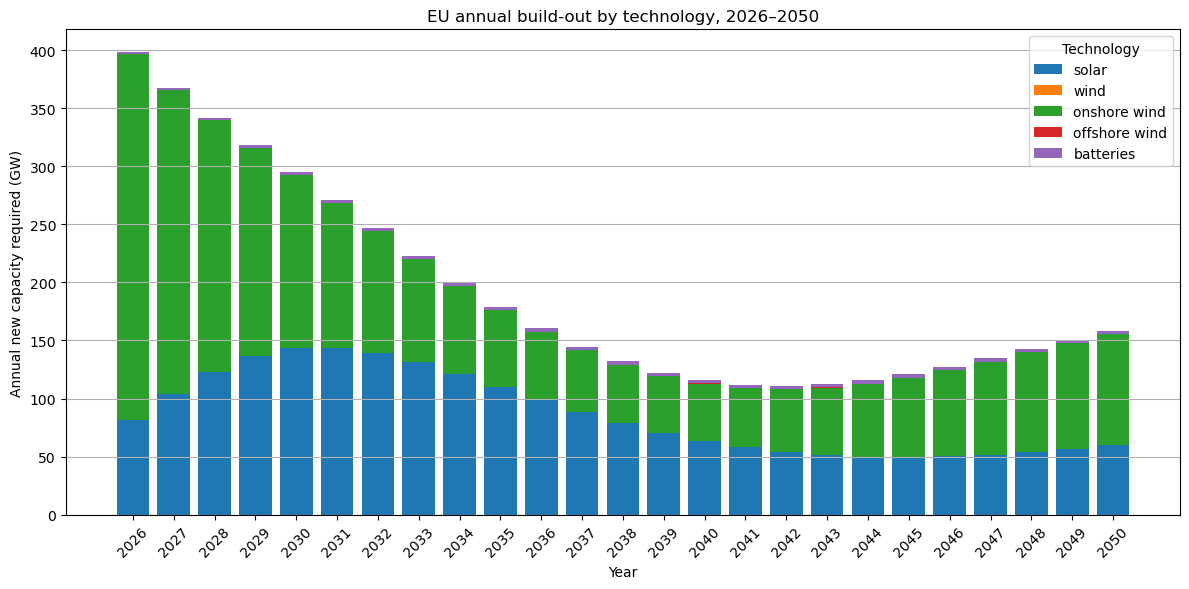

In [14]:
plt.figure(figsize=(12, 6))

bottom = np.zeros(len(buildout_pivot))

for tech in techs_to_plot:
    plt.bar(
        buildout_pivot.index,
        buildout_pivot[tech],
        bottom=bottom,
        label=tech
    )
    bottom += buildout_pivot[tech].values

plt.xlabel("Year")
plt.ylabel("Annual new capacity required (GW)")
plt.title("EU annual build-out by technology, 2026–2050")
plt.xticks(buildout_pivot.index, rotation=45)
plt.legend(title="Technology")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

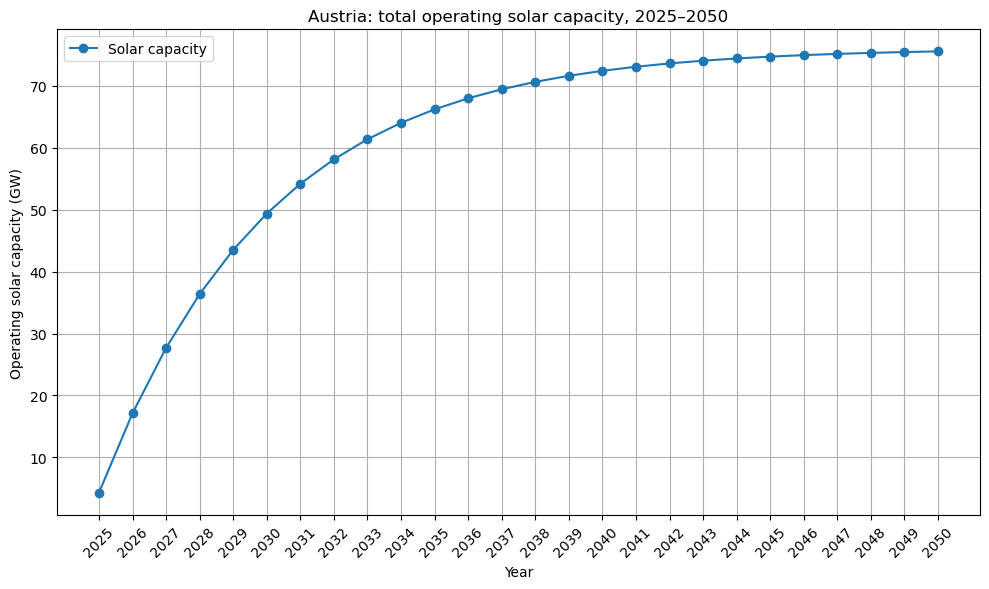

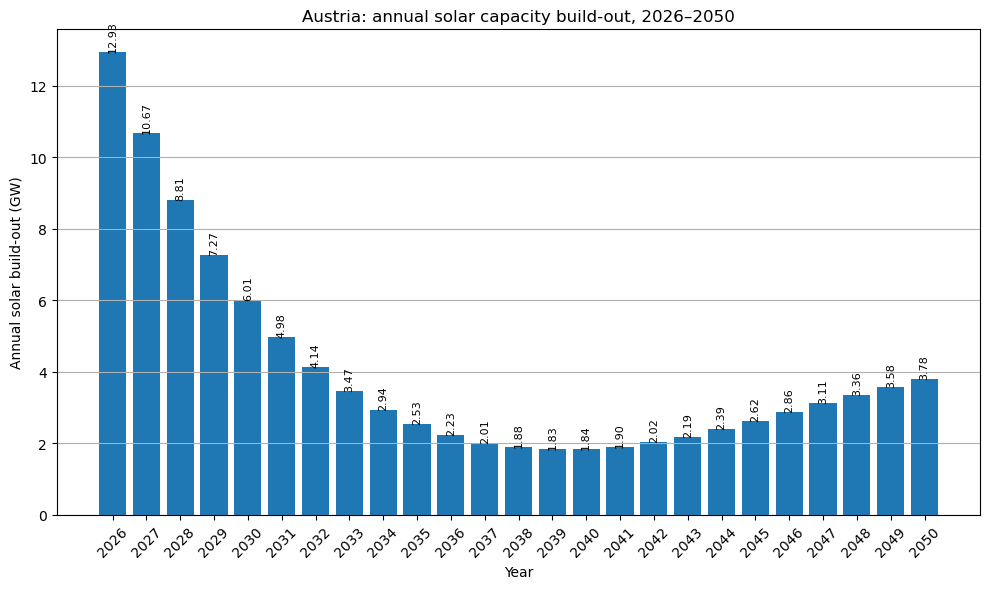

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Data selecteren: Austria + solar
# ---------------------------------------------------------

country = "AUT"
tech = "onshore wind"

df_aut_solar = annual_buildout_df[
    (annual_buildout_df["country"] == country) &
    (annual_buildout_df["tech"] == tech)
].copy()

df_aut_solar = df_aut_solar.sort_values("year")

# Omrekenen van TW naar GW
df_aut_solar["operating_capacity_GW"] = (
    df_aut_solar["operating_capacity_after_build_TW"] * 1000
)

df_aut_solar["new_capacity_required_GW"] = (
    df_aut_solar["new_capacity_required_TW"] * 1000
)


# ---------------------------------------------------------
# 2025 startcapaciteit toevoegen aan de capacity line plot
# ---------------------------------------------------------

capacity_2025_GW = EU_capacities_2025[country][tech] * 1000

start_row = pd.DataFrame([{
    "year": 2025,
    "operating_capacity_GW": capacity_2025_GW
}])

capacity_plot_data = pd.concat(
    [
        start_row,
        df_aut_solar[["year", "operating_capacity_GW"]]
    ],
    ignore_index=True
)

capacity_plot_data = capacity_plot_data.sort_values("year")


# ---------------------------------------------------------
# Figuur 1: totale solar capacity in Oostenrijk
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    capacity_plot_data["year"],
    capacity_plot_data["operating_capacity_GW"],
    marker="o",
    label="Solar capacity"
)

plt.xlabel("Year")
plt.ylabel("Operating solar capacity (GW)")
plt.title("Austria: total operating solar capacity, 2025–2050")
plt.xticks(capacity_plot_data["year"], rotation=45)
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Figuur 2: jaarlijkse solar build-out in Oostenrijk
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

bars = plt.bar(
    df_aut_solar["year"],
    df_aut_solar["new_capacity_required_GW"]
)

plt.xlabel("Year")
plt.ylabel("Annual solar build-out (GW)")
plt.title("Austria: annual solar capacity build-out, 2026–2050")
plt.xticks(df_aut_solar["year"], rotation=45)
plt.grid(axis="y")

# Getallen boven de balken
for bar in bars:
    height = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=90
    )

plt.tight_layout()
plt.show()

Material Demand

In [16]:
buildout = annual_buildout_df[
    [
        "country",
        "year",
        "tech",
        "new_capacity_required_TW"
    ]
].copy()

# Alleen positieve nieuwbouw meenemen
buildout["new_capacity_required_TW"] = (
    buildout["new_capacity_required_TW"].clip(lower=0)
)

material_demand = buildout.merge(
    material_intensities[
        [
            "tech",
            "Material",
            "Material Intensity (ton/TW)"
        ]
    ],
    on="tech",
    how="left"
)



material_demand["material_required_tonnes"] = (
    material_demand["new_capacity_required_TW"]
    * material_demand["Material Intensity (ton/TW)"]
)



materials_country_year = (
    material_demand
    .groupby(
        ["country", "year", "Material"],
        as_index=False
    )["material_required_tonnes"]
    .sum()
)



materials_EU_year = (
    material_demand
    .groupby(
        ["year", "Material"],
        as_index=False
    )["material_required_tonnes"]
    .sum()
)


print("\nEU-totaal per jaar:")
print(materials_EU_year)


EU-totaal per jaar:
     year            Material  material_required_tonnes
0    2026            aluminum              1.956188e+06
1    2026               boron              3.793368e+03
2    2026            chromium              3.920580e+05
3    2026              cobalt              9.484182e+02
4    2026              copper              9.850159e+05
..    ...                 ...                       ...
645  2050  sum of rare earths              4.151726e+03
646  2050                 tin              4.073512e+03
647  2050            titanium              7.386903e+03
648  2050            tungsten              0.000000e+00
649  2050                zinc              8.671967e+04

[650 rows x 3 columns]
